# Beyond pairwise correlation: capturing nonlinear and higher-order

dependence with distance statistics

Benjamin Avanzi (Centre for Actuarial Studies, Department of Economics, University of Melbourne, Australia)  
Guillaume Boglioni Beaulieu (School of Risk and Actuarial Studies, University of New South Wales, Sydney, NSW 2052, Australia)  
Pierre Lafaye de Micheaux (School of Mathematics and Statistics, University of New South Wales, Sydney, NSW 2052, Australia)  
Ho Ming Lee (Centre for Actuarial Studies, Department of Economics, University of Melbourne, Australia, Faculty of Economics and Business, KU Leuven, Belgium)  
Bernard Wong (School of Risk and Actuarial Studies, University of New South Wales, Sydney, NSW 2052, Australia)  
Rui Zhou (Centre for Actuarial Studies, Department of Economics, University of Melbourne, Australia)

In [ ]:
# Loading required libraries
library(ggplot2)
library(patchwork)
library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: energy

Loading required package: FNN

Loading required package: orthopolynom


Attaching package: 'dcov'

The following objects are masked from 'package:energy':

    dcor, dcor.test, dcor2d, dcov, dcov2d, pdcor, pdcor.test, pdcov

In [ ]:
get_pmat_corr <- function(dat, method = c("pearson", "spearman", "kendall"),
                          R = 9999) {
  # This function is used to get the p-values for testing correlation significance
  # Input: a dataframe with all numerical columns
  # output: p-value matrix of the choice of correlation
  method <- match.arg(method)
  
  dat <- as.data.frame(dat)
  pmat <- matrix(NA_real_, ncol(dat), ncol(dat))
  colnames(pmat) <- rownames(pmat) <- colnames(dat)
  
  for (i in 1:(ncol(dat) - 1)) {
    for (j in (i + 1):ncol(dat)) {
      x <- dat[[i]]
      y <- dat[[j]]
      
      keep <- complete.cases(x, y)
      x <- x[keep]
      y <- y[keep]
      
      pval <- if (method == "pearson") {
        TOSTER::boot_cor_test(x, y, method = "pearson", null = 0, alternative = "two.sided", R = R)$p.value
      } else {
        cor.test(x, y, method = method)$p.value
      }
      
      pmat[i, j] <- pval
      pmat[j, i] <- pval
    }
  }
  
  diag(pmat) <- NA
  pmat
}

# Introduction

This is the code for the paper \`\`Beyond pairwise correlation: capturing nonlinear and higher-order dependence with distance statistics” by Benjamin Avanzi, Guillaume Boglioni Beaulieu, Pierre Lafaye de Micheaux, Ho Ming Lee, Bernard Wong, and Rui Zhou.

## Motivating examples

This section provide the codes for generating the figures and statistics in the introduction of the paper, as well as the data generation process for simulated data.

### 2020 birth and death rates

Our first motivating example involves the birth and death rate data from different countries in the first trimester of 2020 \[@CIA_WorldFactbook_worlddemographics\]. This example is to illustrate that correlations are inherently for linear and monotonic relationships and hence a 0 correlation does not mean independence, and a small value does not necessarily means the actual dependence relationship is weak.

The birth and death rates are measured as the numbers of births and deaths per 1000 individuals, respectively, across 229 countries. The data can be loaded through the `HellCor` package in `R`.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'

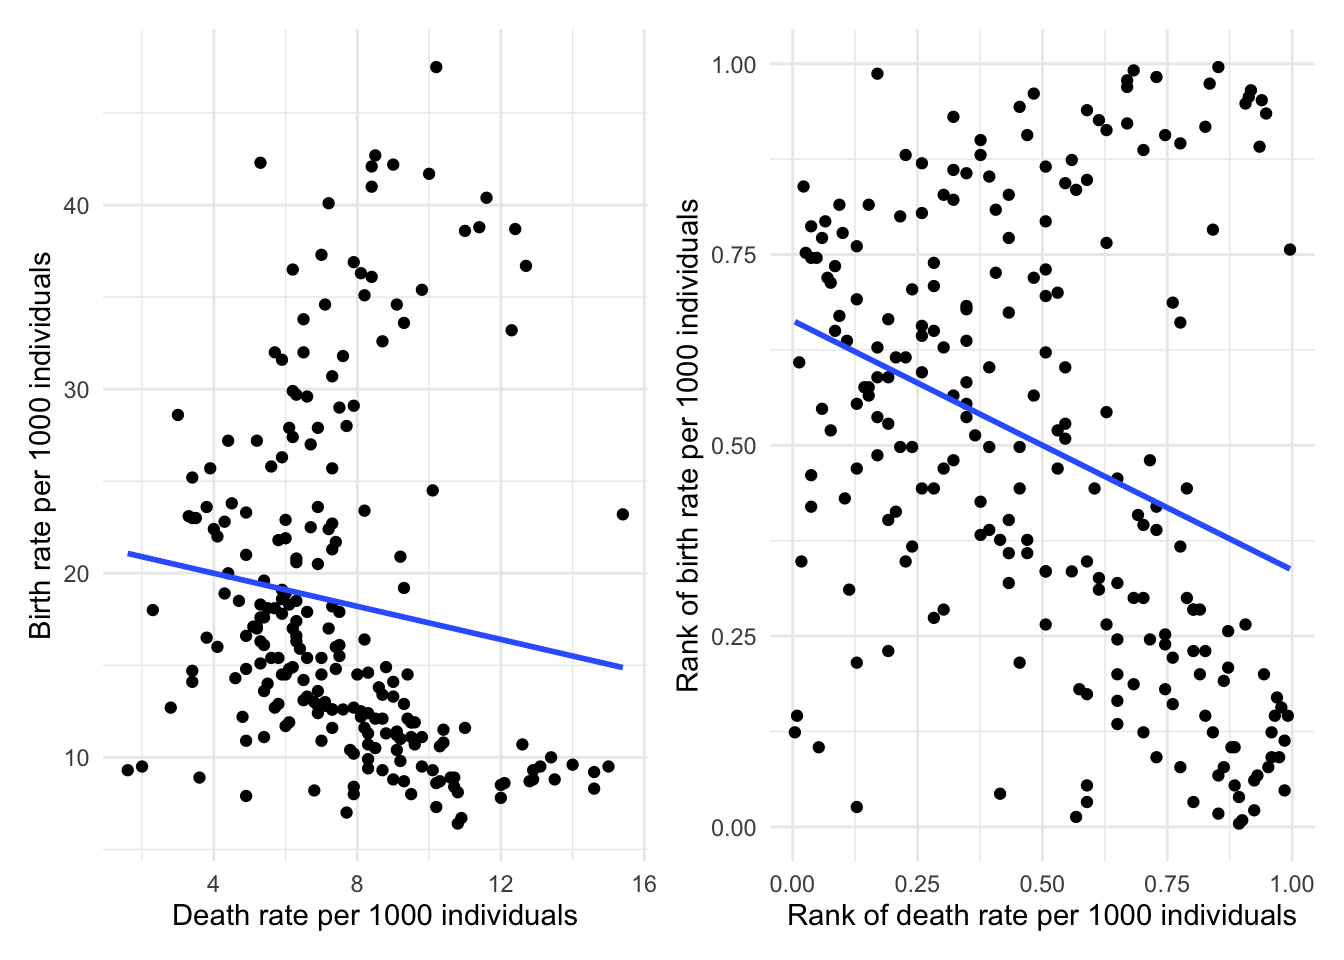

In [ ]:
# Load birth vs death rate data
data("worlddemographics")

# Transform the data into ranks
worlddemographics_rank <- worlddemographics |>
  transform(
    FDeath = rank(Death.Rate.Pop) / (nrow(worlddemographics) + 1),
    FBirth = rank(Birth.Rate.Pop) / (nrow(worlddemographics) + 1)
  )

# Plotting both the raw data (p1) and the ranks (p2) out
p1 <- ggplot(worlddemographics, aes(x = Death.Rate.Pop, y = Birth.Rate.Pop)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    x = "Death rate per 1000 individuals",
    y = "Birth rate per 1000 individuals"
  ) +
  theme_minimal()

p2 <- ggplot(worlddemographics_rank, aes(x = FDeath, y = FBirth)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    x = "Rank of death rate per 1000 individuals",
    y = "Rank of birth rate per 1000 individuals"
  ) +
  theme_minimal()

p1 + p2

The corresponding correlation coefficients, and the corresponding $p$-values with the null hypothesis
$$\begin{aligned}
H_0 &: \theta=0,\\
H_1 &: \theta\neq0,
\end{aligned}$$
for $\theta\in\{r \text{ (Pearson)}, \rho \text{ (Spearman)}, \tau \text{ (Kendall)}\}$ are given by

In [ ]:
# Getting raw data for birth and death
birth_raw <- worlddemographics$Birth.Rate.Pop
death_raw <- worlddemographics$Death.Rate.Pop

set.seed(123) # This is for bootstrap test for correlation
cor_matrix_birth_death <- rbind(
  correlation = c(
    cor.test(birth_raw, death_raw, method = "pearson")$estimate,
    cor.test(birth_raw, death_raw, method = "spearman")$estimate,
    cor.test(birth_raw, death_raw, method = "kendall")$estimate
  ),
  p_value = c(
    # p-val for Pearson's corr needs boostrap here
    # As the null of the t-test assumed bivariate normal,
    # which is not necessarily true in this case.
    TOSTER::boot_cor_test(birth_raw, death_raw)$p.value, 
    cor.test(birth_raw, death_raw, method = "spearman")$p.value,
    cor.test(birth_raw, death_raw, method = "kendall")$p.value
  )
)

Warning in cor.test.default(birth_raw, death_raw, method = "spearman"): Cannot
compute exact p-value with ties
Warning in cor.test.default(birth_raw, death_raw, method = "spearman"): Cannot
compute exact p-value with ties

                Pearson      Spearman       Kendall
correlation -0.12513158 -3.268202e-01 -2.359474e-01
p_value      0.06503252  4.232096e-07  1.319531e-07

### Multi-line example

The other example is used to illustrate that the correlation is inherently pairwise, and it cannot detect association when the underlying association exist when they considered jointly. For this example, there are two business lines where we have the motor line with the following components: and $Y$ denotes the medical claim cost recorded under another line of business. The data is simulated using the following code

In [ ]:
set.seed(123)
n <- 5000

U1 <- runif(n) # latent for vehicle repair
U2 <- runif(n) # latent for bodily injury liability
U3 <- runif(n) # latent for claims handling

# latent for medical claims - it depends on both 
# vehicle damage and bodily injury
C <- (U1 + U2) %% 1 

# Independently distributed in Gamma
X1 <- qgamma(U1, shape = 2.5, scale = 2000)
X2 <- qgamma(U2, shape = 3.0, scale = 3000)

# Gamma as well, but dependends on (X1, X2)
Y <- qgamma(C, shape = 2.2, scale = 2500)

# Here we have claims handling cost, and there are two types of claim:
# Severity driven: handling cost goes up with medical cost (C)
# Review driven: handling cost higher for smaller medical cost (1-C)
p <- 0.50
R <- rbinom(n, size = 1, prob = p)
W <- ifelse(R == 1, C, 1 - C)

X3 <- qgamma(W, shape = 2.0, scale = 1200)

multi_line_dat <- data.frame(X1,X2,X3,Y)

Below we apply some exploratory data analysis. First, we look at the distribution of each of the claim costs. As expected, all of the shape looks like a $\Gamma$-distribution:

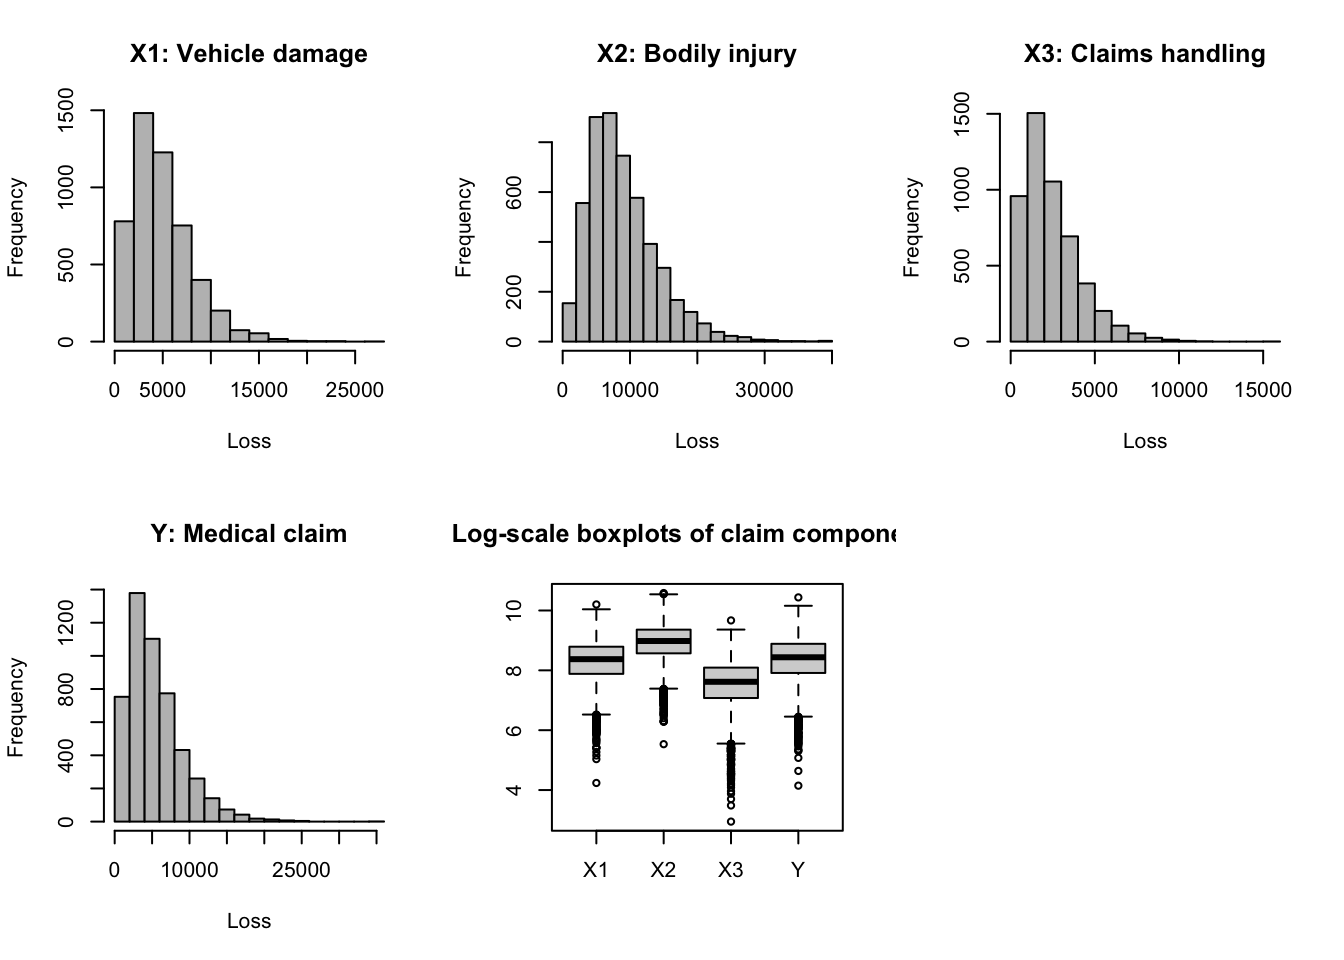

In [ ]:
par(mfrow = c(2,3))

# Histogram for each of the claim costs
hist(multi_line_dat$X1, main = "X1: Vehicle damage", xlab = "Loss", col = "grey")
hist(multi_line_dat$X2, main = "X2: Bodily injury", xlab = "Loss", col = "grey")
hist(multi_line_dat$X3, main = "X3: Claims handling", xlab = "Loss", col = "grey")
hist(multi_line_dat$Y, main = "Y: Medical claim", xlab = "Loss", col = "grey")

# Boxplot for log claim components
boxplot(log(multi_line_dat[, c("X1","X2","X3","Y")]),
        main = "Log-scale boxplots of claim components")

Then, we apply bivariate analysis. First, we plot the scatter plots for each pair of the variables using their ranks. Here ranks are used to reveal the dependence structure between the pairs.

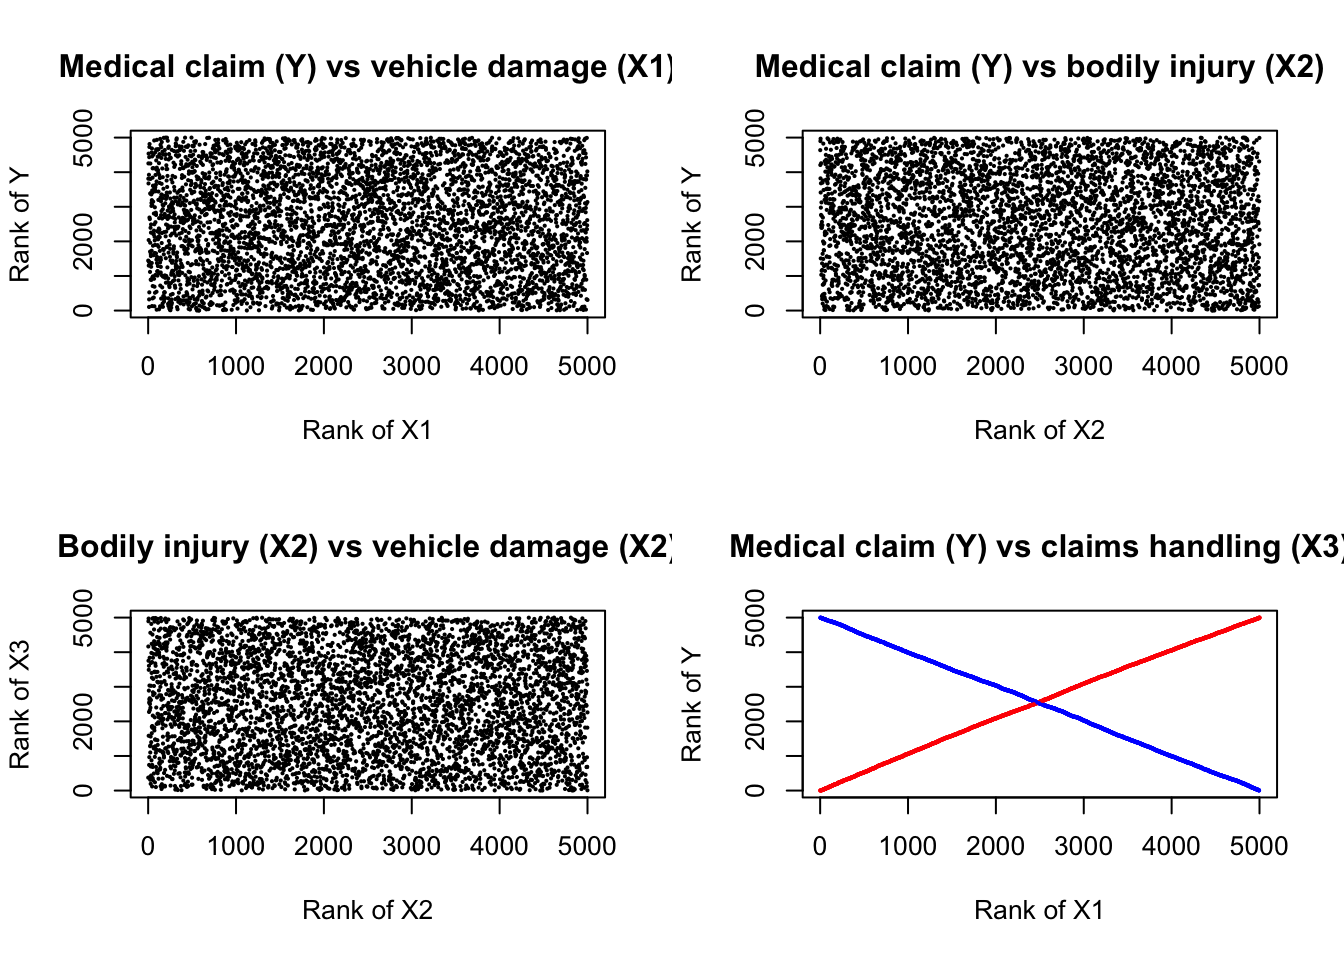

In [ ]:
par(mfrow = c(2,2))
col_group <- ifelse(R == 1, "red", "blue")
plot(rank(multi_line_dat$X1), rank(multi_line_dat$Y), pch = 16, cex = 0.35,
     xlab = "Rank of X1", ylab = "Rank of Y",
     main = "Medical claim (Y) vs vehicle damage (X1)")

plot(rank(multi_line_dat$X2), rank(multi_line_dat$Y), pch = 16, cex = 0.35,
     xlab = "Rank of X2", ylab = "Rank of Y",
     main = "Medical claim (Y) vs bodily injury (X2)")

plot(rank(multi_line_dat$X2), rank(multi_line_dat$X3), pch = 16, cex = 0.35,
     xlab = "Rank of X2", ylab = "Rank of X3",
     main = "Bodily injury (X2) vs vehicle damage (X2)")

plot(rank(multi_line_dat$X3), rank(multi_line_dat$Y), pch = 16, cex = 0.35,
     col = col_group, xlab = "Rank of X1", ylab = "Rank of Y",
     main = "Medical claim (Y) vs claims handling (X3)")

The correlation and the corresponding $p$-value matrices are given by below:

In [ ]:
cor(multi_line_dat) # Pearson correlation

             X1           X2          X3           Y
X1  1.000000000 -0.025932480 0.001279202 -0.01000060
X2 -0.025932480  1.000000000 0.006776664 -0.02001201
X3  0.001279202  0.006776664 1.000000000  0.07614912
Y  -0.010000596 -0.020012013 0.076149119  1.00000000

          X1        X2        X3         Y
X1        NA 0.0870087 0.9362936 0.4866487
X2 0.0870087        NA 0.6576658 0.1978198
X3 0.9362936 0.6576658        NA 0.0050005
Y  0.4866487 0.1978198 0.0050005        NA

             X1           X2           X3           Y
X1  1.000000000 -0.019885108 -0.009221736 -0.01336648
X2 -0.019885108  1.000000000  0.007085466 -0.02314468
X3 -0.009221736  0.007085466  1.000000000 -0.01399048
Y  -0.013366483 -0.023144684 -0.013990480  1.00000000

          X1        X2        X3         Y
X1        NA 0.1597607 0.5144489 0.3446798
X2 0.1597607        NA 0.6164421 0.1017588
X3 0.5144489 0.6164421        NA 0.3226253
Y  0.3446798 0.1017588 0.3226253        NA

             X1           X2           X3            Y
X1  1.000000000 -0.013227766 -0.006103941 -0.008739668
X2 -0.013227766  1.000000000  0.004754391 -0.015579916
X3 -0.006103941  0.004754391  1.000000000 -0.012888658
Y  -0.008739668 -0.015579916 -0.012888658  1.000000000

          X1         X2        X3          Y
X1        NA 0.16075838 0.5175063 0.35410443
X2 0.1607584         NA 0.6141891 0.09855056
X3 0.5175063 0.61418909        NA 0.17176004
Y  0.3541044 0.09855056 0.1717600         NA

Here, as we can see the pairs $(X_1,X_2)$, $(X_1,Y)$, and $(X_2,Y)$ does not show any obvious pattern, suggesting independence. However, when we look at the scatter plot between $(X_1,X_2)$ coloured by $Y$, we can see that the value of $Y$ forms a diganoal pattern, i.e. knowing the value of $(X_1,X_2)$ provide information of $Y$, suggesting that they are not mutually independent. This raise one of the pitfall that correlation, and in general, thinking in pairwise dependence, can miss strutures where the dependence is considered jointly.

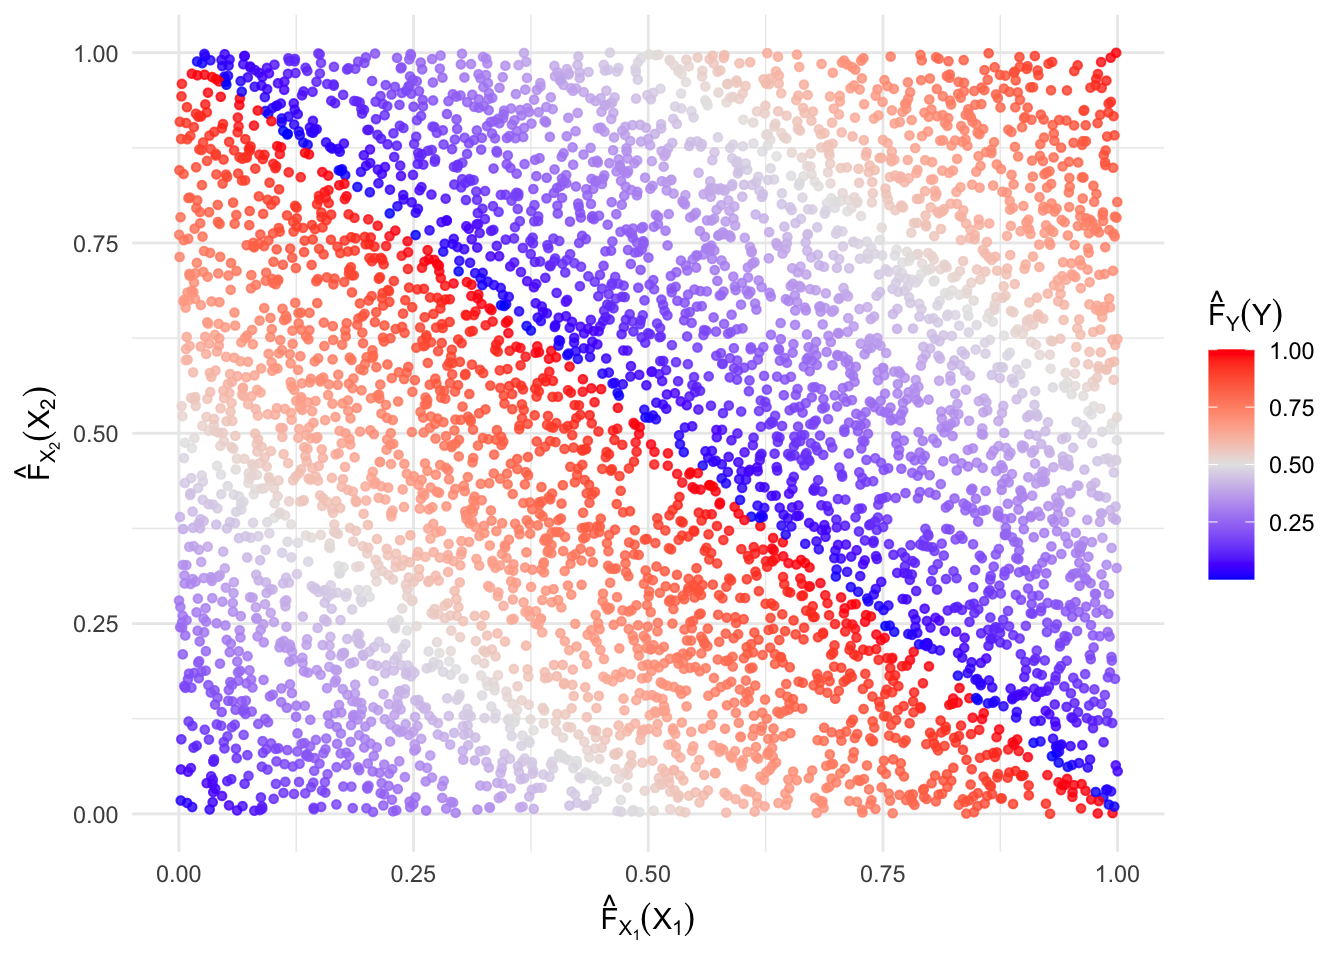

In [ ]:
# build eCDF for the multi-line data
multi_line_ECDF <- multi_line_dat %>%
  mutate(
    FX1 = rank(X1) / n(),
    FX2 = rank(X2) / n(),
    FX3 = rank(X3) / n(),
    FY = rank(Y) / n()
  )

ggplot(multi_line_ECDF, aes(x = FX1, y = FX2, colour = FY)) + 
  geom_point(size = 1.2, alpha = 0.8) + 
  scale_colour_gradient2(
    low = "blue",
    mid = "grey90",
    high = "red",
    midpoint = 0.5,
    name = expression(hat(F)[Y](Y))
  ) +
  labs(
    x = expression(hat(F)[X[1]](X[1])),
    y = expression(hat(F)[X[2]](X[2]))
  ) + 
  theme_minimal()

### Failure of CLT

Another important implication of relying on pairwise dependence statistics is that, many of the actuarial modelling assumption relies on the assumption that the random variables are (mutually) independent and identically distributed. It is possible to construct a sequence of identical and pairwise independent random variables but not mutually independent. However, this cannot be detected through bivariate dependence statistics such as the correlation. And it is possible that the central limit theorem (CLT) fails for such a sequence of random variables.

As illustrated by @avanzi2021counterexample and @beaulieu2021counterexamples, pairwise independence alone does not guarantee asymptotic normality. They construct a sequence $X_1,\ldots,X_n$ of pairwise independent, but not mutually independent, standard normal random variables such that the limiting distribution of coincides with that of the random variable where $Z\sim N(0,1)$, $\chi$ is a standardised chi-squared random variable independent of $Z$, and $0<r^2<1$. The limiting distribution does not necessarily converge to the normal distribution, as the CLT suggests.

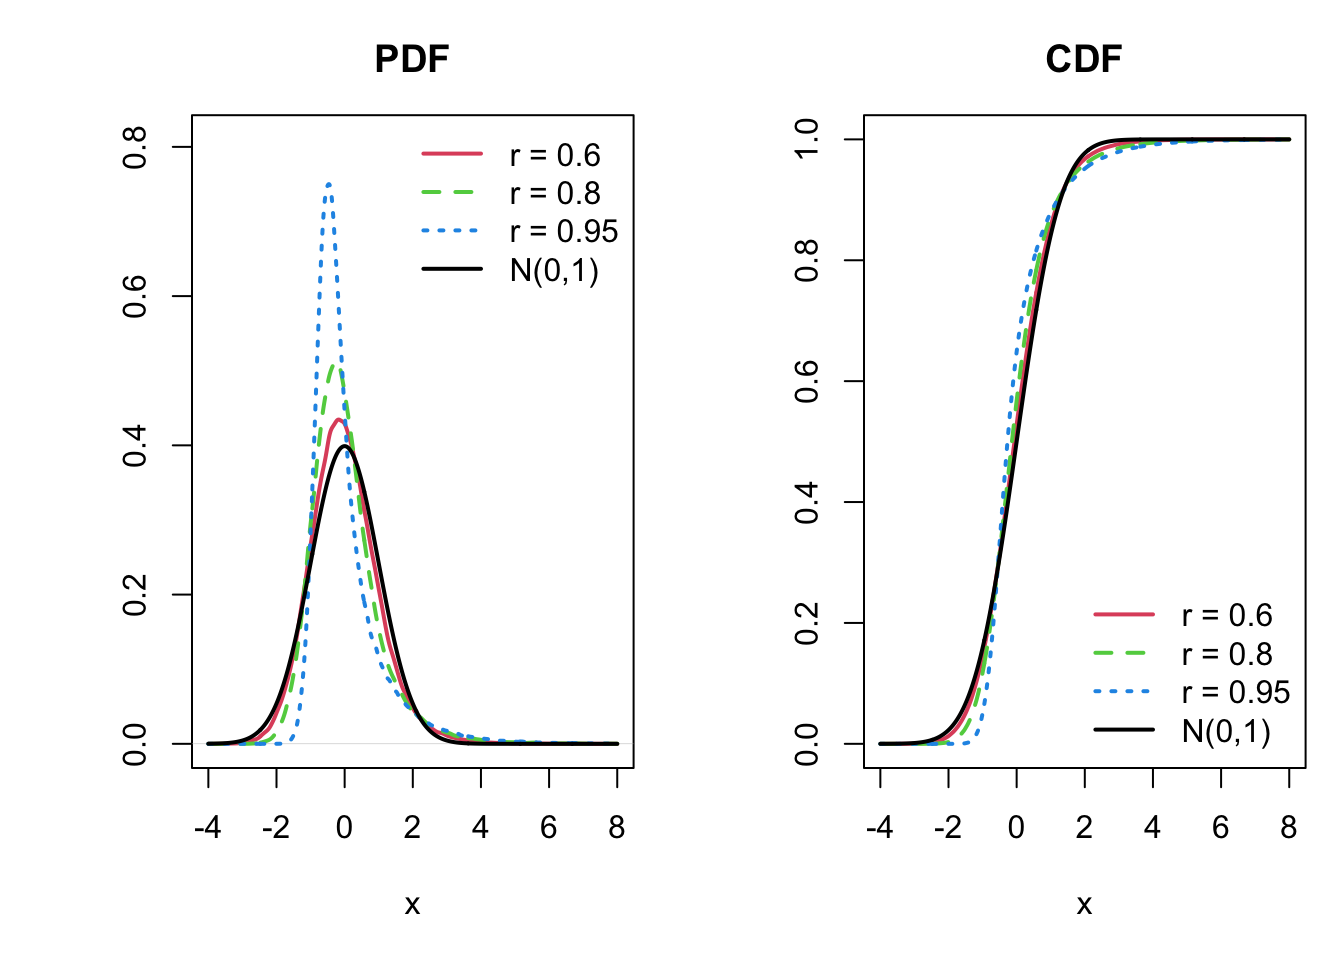

In [ ]:
set.seed(123)

# standardised chi-squared distribution with df = 1
rchi_std <- function(n){
  (rchisq(n, df = 1)-1)/sqrt(2)
}

rS <- function(n, r){
  sqrt(1 - r^2) * rnorm(n) + r * rchi_std(n)
}

r_vals <- c(0.6, 0.8, 0.95)
n <- 300000
x_grid <- seq(-4, 8, length.out = 1000)

samples <- lapply(r_vals, function(r) rS(n, r))
densities <- lapply(samples, density,
                    from = min(x_grid), to = max(x_grid),
                    n = 1000)

ymax <- max(
  sapply(densities, function(d) max(d$y)),
  max(dnorm(x_grid))
)
ymax <- 1.08 * ymax

par(mfrow = c(1,2), mar = c(5,5,3,1))
# ----- left panel: PDF -----
plot(densities[[1]], type = "l", lwd = 2, col = 2,
     main = "PDF", xlab = "x", ylab = "",
     xlim = range(x_grid), ylim = c(0, ymax))

for (i in 2:length(densities)) {
  lines(densities[[i]], lwd = 2, col = i + 1, lty = i)
}
lines(x_grid, dnorm(x_grid), lwd = 2, col = 1)

legend("topright",
       legend = c(paste0("r = ", r_vals), "N(0,1)"),
       col = c(2, 3, 4, 1),
       lty = c(1, 2, 3, 1),
       lwd = 2,
       bty = "n")

# ----- right panel: CDF -----
plot(x_grid, ecdf(samples[[1]])(x_grid), type = "l", lwd = 2, col = 2,
     main = "CDF", xlab = "x", ylab = "",
     xlim = range(x_grid), ylim = c(0, 1))

for (i in 2:length(samples)) {
  lines(x_grid, ecdf(samples[[i]])(x_grid),
        lwd = 2, col = i + 1, lty = i)
}
lines(x_grid, pnorm(x_grid), lwd = 2, col = 1)

legend("bottomright",
       legend = c(paste0("r = ", r_vals), "N(0,1)"),
       col = c(2, 3, 4, 1),
       lty = c(1, 2, 3, 1),
       lwd = 2,
       bty = "n")

## Illustration with Hellinger correlation

## Illustration with distance covariance/correlation

## Time series

In [ ]:
library(quantmod)

Loading required package: xts

Loading required package: zoo


Attaching package: 'zoo'

The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's namespace mechanism #
# Set `options(xts.warn_dplyr_breaks_lag = FALSE)` to suppress this warning.  #
#                                      

...

Loading required package: TTR

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

[1] "GSPC"

Warning in adf.test(ret): p-value smaller than printed p-value


    Augmented Dickey-Fuller Test

data:  ret
Dickey-Fuller = -9.3883, Lag order = 10, p-value = 0.01
alternative hypothesis: stationary

In [ ]:
library(dCovTS)


dCovTS: 1.4

               _ _ _ _                            _ _ _ _ _    _ _ _ _ _
       _      /   _ _ _\                         |_ _   _ _|  |  _ _ _ _/
      | |    /  /                                    | |      | |
 _ _ _| |    | |           _ _ _ _    _      _       | |      | |_ _ _ _ 
|  _ _  |    | |          |  _ _  |  \ \    / /      | |      |_ _ _ _  |
| |   | |    | |          | |   | |   \ \  / /       | |              | |
| |_ _| |_   \  \ _ _ _   | |_ _| |    \ \/ /        | |       _ _ _ _| |
|_ _ _ _ _|   \_ _ _ _ /  |_ _ _ _|     \__/         |_|      /_ _ _ _ _|

Loading required package: MASS


Attaching package: 'MASS'

The following object is masked from 'package:dplyr':

    select

...

Loading required package: urca

Loading required package: lmtest

                  1           2           3           4           5           6
AIC(n)     11.84541    11.35895    11.32363    11.28376    11.23095    11.20946
HQ(n)      11.88523    11.42864    11.42318    11.41318    11.39023    11.39861
SC(n)      11.94687    11.53651    11.57728    11.61351    11.63679    11.69140
FPE(n) 139442.85952 85730.12941 82755.88760 79522.85813 75434.43083 73833.93231
                 7           8           9          10
AIC(n)    11.21508    11.19717    11.17261    11.17843
HQ(n)     11.43409    11.44604    11.45134    11.48703
SC(n)     11.77311    11.83130    11.88283    11.96475
FPE(n) 74254.62493 72942.17171 71179.59211 71604.50745

AIC(n)  HQ(n)  SC(n) FPE(n) 
     9      5      2      9 


VAR Estimation Results:
Endogenous variables: cmort, tempr, part 
Deterministic variables: const 
Sample size: 506 
Log Likelihood: -5002.728 
Roots of the characteristic polynomial:
0.8995 0.8995 0.6184 0.4889 0.4709 0.4709
Call:
VAR(y = x, p = 2, type = "const")


Estimation results for equation cmort: 
cmort = cmort.l1 + tempr.l1 + part.l1 + cmort.l2 + tempr.l2 + part.l2 + const 

         Estimate Std. Error t value Pr(>|t|)    
cmort.l1  0.36966    0.04295   8.607  < 2e-16 ***
tempr.l1 -0.17253    0.04530  -3.809 0.000157 ***
part.l1   0.03153    0.02465   1.279 0.201479    
cmort.l2  0.34065    0.04148   8.213 1.86e-15 ***
tempr.l2 -0.03657    0.04530  -0.807 0.419874    
part.l2   0.05154    0.02585   1.994 0.046690 *  
const    37.24529    4.98318   7.474 3.51e-13 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Residual standard error: 5.45 on 499 degrees of freedom
Multiple R-Squared: 0.7056, Adjusted R-squared: 0.7021 
F-statistic: 199.3 on 6 and 499

In [ ]:
# install.packages("tseries")

cmort_ts <- ts(MortTempPart$cmort) 
tempr_ts <- ts(MortTempPart$tempr) 
part_ts <- ts(MortTempPart$part) 

adf.test(cmort_ts)

Warning in adf.test(cmort_ts): p-value smaller than printed p-value


    Augmented Dickey-Fuller Test

data:  cmort_ts
Dickey-Fuller = -5.4125, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary

Warning in adf.test(tempr_ts): p-value smaller than printed p-value


    Augmented Dickey-Fuller Test

data:  tempr_ts
Dickey-Fuller = -4.4572, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary

Warning in adf.test(part_ts): p-value smaller than printed p-value


    Augmented Dickey-Fuller Test

data:  part_ts
Dickey-Fuller = -4.493, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary